In [2]:
#Descriptive Statistics

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("final_df.csv").rename(
    columns={"Unternehmensname Latin alphabet": "firma"}
)

In [5]:
df.columns

Index(['firma', 'Bilanzsumme', 'Jahr', 'Zahlungsmittel', 'ROA', 'Eigenkapital',
       'Kurzfristige_Verbindlichkeiten', 'Langfristige_Verbindlichkeiten',
       'EK_Quote', 'Umsatz', 'Zinsschock', 'ABS', 'Zinswende_Dummy',
       'Cash_Ratio', 'Groesse_Log_Bilanzsumme', 'Leverage', 'Leverage_exante',
       'Liquidity_exante', 'STDebtShare', 'STDebtShare_exante'],
      dtype='object')

In [6]:
#Differenz EKQ
df["dEKQ"] = df.groupby("firma")["EK_Quote"].diff()

In [7]:
# Deskriptive Statistik berechnen
desc = df[[
    "EK_Quote",
    "dEKQ",
    "Zinsschock",
    "Leverage_exante",
    "Liquidity_exante",
    "STDebtShare_exante",
    "ROA",
    "Cash_Ratio",
    "Groesse_Log_Bilanzsumme"
]].describe().T

# Relevante Kennzahlen auswählen
desc = desc[["count", "mean", "50%", "std", "min", "max"]]

# Spalten umbenennen
desc.columns = [
    "N",
    "Mittelwert",
    "Median",
    "Std.-Abw.",
    "Minimum",
    "Maximum"
]

# Zeilen umbenennen
desc.index = [
    "Eigenkapitalquote",
    "Differenz Eigenkapitalquote",
    "Zinsschock",
    "Verschuldungsgrad",
    "Liquidität",
    "Anteil kurzfristiger Verschuldung",
    "ROA",
    "Cash Ratio",
    "Unternehmensgrösse"
]

# Werte runden
desc = desc.round(2)

# Tabelle anzeigen
print(desc)

                                        N  Mittelwert  Median  Std.-Abw.  \
Eigenkapitalquote                  2853.0       44.29   43.99      22.20   
Differenz Eigenkapitalquote        2540.0       -0.10    0.10       7.06   
Zinsschock                         2853.0       -3.00   -0.04      14.83   
Verschuldungsgrad                  2853.0        0.56    0.56       0.21   
Liquidität                         2853.0        0.13    0.09       0.13   
Anteil kurzfristiger Verschuldung  2853.0        0.40    0.37       0.24   
ROA                                2853.0        2.99    2.48       7.64   
Cash Ratio                         2853.0        0.13    0.09       0.14   
Unternehmensgrösse                 2853.0        5.68    5.44       2.01   

                                   Minimum  Maximum  
Eigenkapitalquote                   -98.22    93.80  
Differenz Eigenkapitalquote        -115.83    58.64  
Zinsschock                          -33.39    22.60  
Verschuldungsgrad      

In [8]:
#Anzahl Unternehmen
anzahl_unternehmen = df["firma"].nunique()

print("Anzahl Unternehmen:", anzahl_unternehmen)

Anzahl Unternehmen: 313


In [9]:
#Korrelationsmatrix
corr_vars = [
    "EK_Quote",
    "dEKQ",
    "Leverage_exante",
    "Liquidity_exante",
    "STDebtShare_exante",
    "Groesse_Log_Bilanzsumme",
    "ROA",
    "Cash_Ratio",
    "Zinsschock",
    "ABS"
]

corr_table = df[corr_vars].corr()
print(corr_table.round(3))

                         EK_Quote   dEKQ  Leverage_exante  Liquidity_exante  \
EK_Quote                    1.000  0.173           -0.923             0.148   
dEKQ                        0.173  1.000            0.045             0.013   
Leverage_exante            -0.923  0.045            1.000            -0.140   
Liquidity_exante            0.148  0.013           -0.140             1.000   
STDebtShare_exante          0.384 -0.026           -0.414             0.364   
Groesse_Log_Bilanzsumme    -0.054 -0.031            0.032            -0.192   
ROA                         0.184  0.192           -0.153            -0.040   
Cash_Ratio                  0.150  0.018           -0.124             0.866   
Zinsschock                 -0.002 -0.014            0.000            -0.000   
ABS                        -0.010  0.015           -0.000             0.000   

                         STDebtShare_exante  Groesse_Log_Bilanzsumme    ROA  \
EK_Quote                              0.384        

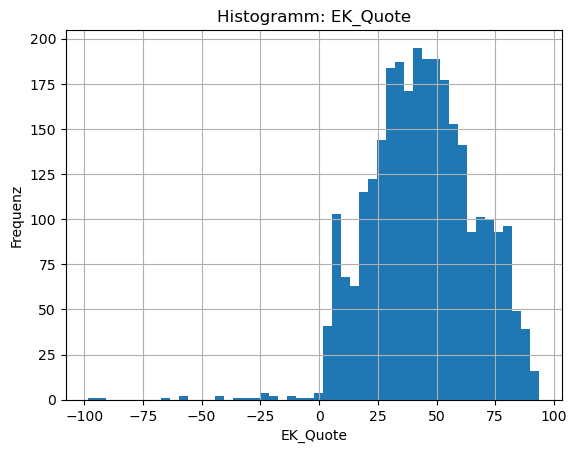

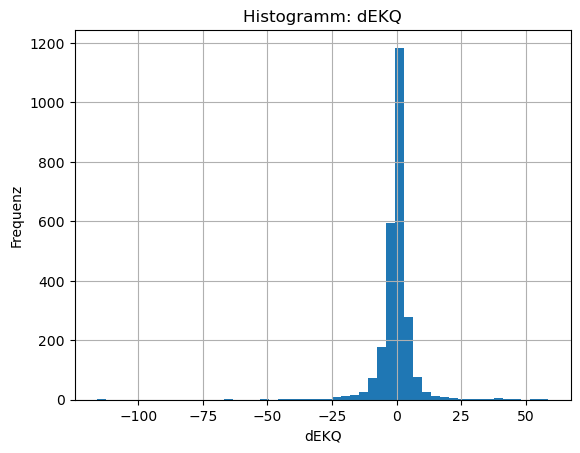

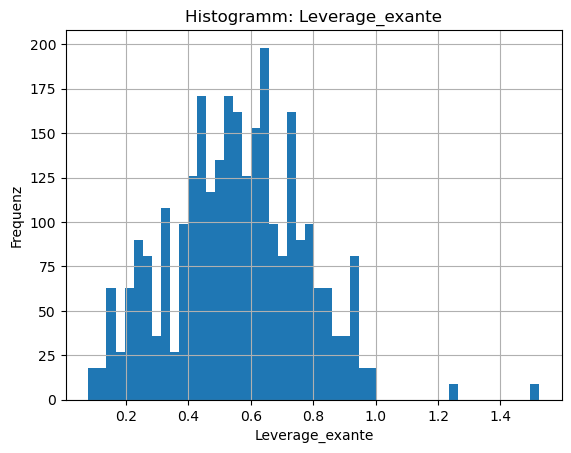

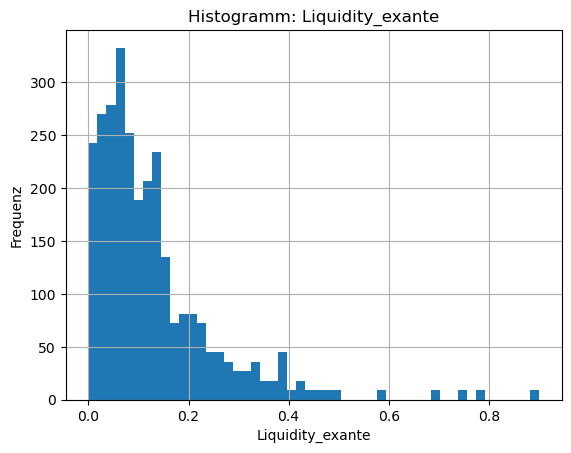

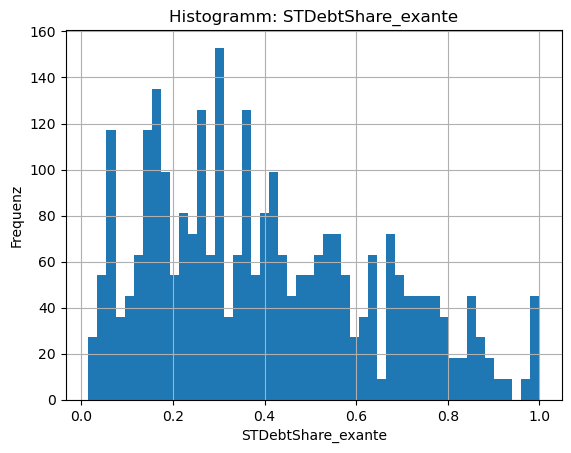

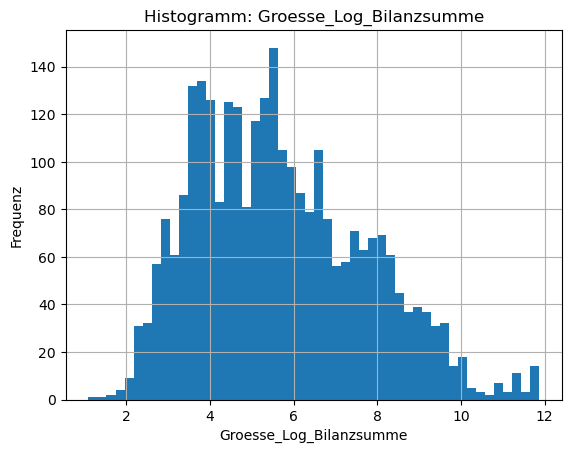

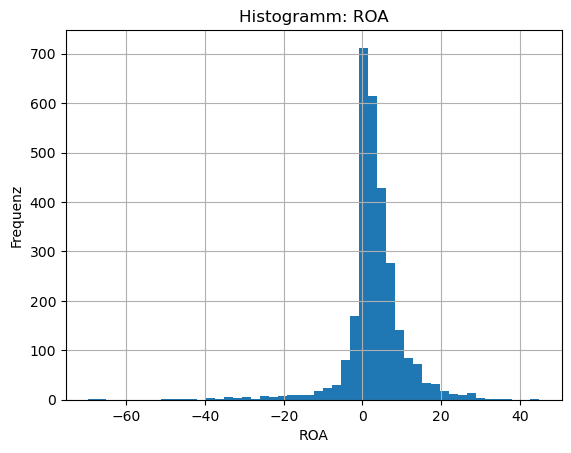

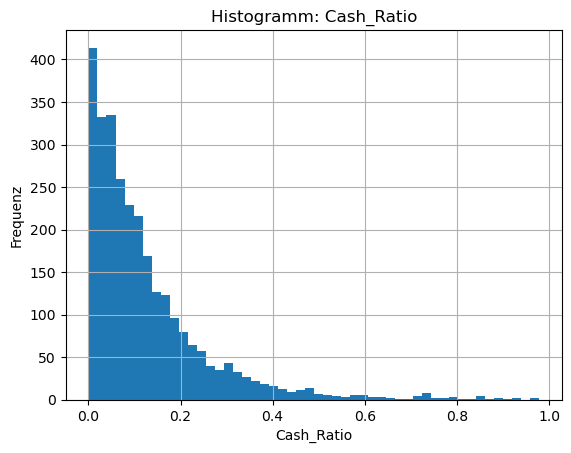

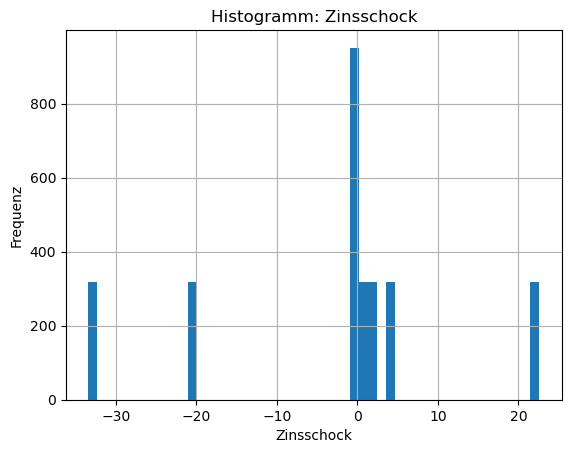

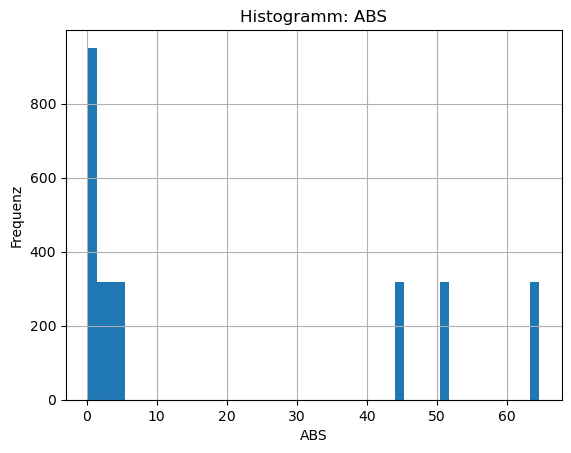

In [10]:
# Verteilung der Variablen
for var in corr_vars:
    plt.figure()
    df[var].hist(bins=50)
    plt.title(f'Histogramm: {var}')
    plt.xlabel(var)
    plt.ylabel('Frequenz')
    plt.show()

   Jahr  Zinsschock
0  2016      -0.440
1  2017      -0.775
2  2018      -0.040
3  2019       1.600
4  2020       3.620
5  2021       0.250
6  2022      22.600
7  2023     -20.407
8  2024     -33.391


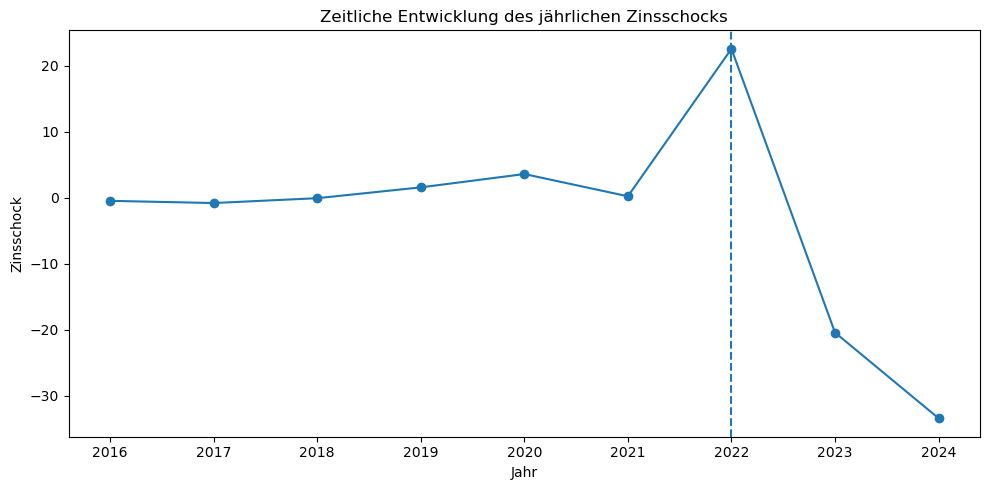

In [11]:
# Entwicklung des Zinsschock
zins_jahr = df.groupby("Jahr", as_index=False)["Zinsschock"].mean()

print(zins_jahr)

plt.figure(figsize=(10, 5))
plt.plot(zins_jahr["Jahr"], zins_jahr["Zinsschock"], marker="o")
plt.axvline(x=2022, linestyle="--")
plt.title("Zeitliche Entwicklung des jährlichen Zinsschocks")
plt.xlabel("Jahr")
plt.ylabel("Zinsschock")
plt.tight_layout()
plt.show()

In [12]:
#Entwicklung des Absoluten Zinsschock

   Jahr     ABS
0  2016   2.840
1  2017   0.775
2  2018   0.720
3  2019   2.000
4  2020   4.900
5  2021   0.250
6  2022  64.600
7  2023  44.581
8  2024  50.823


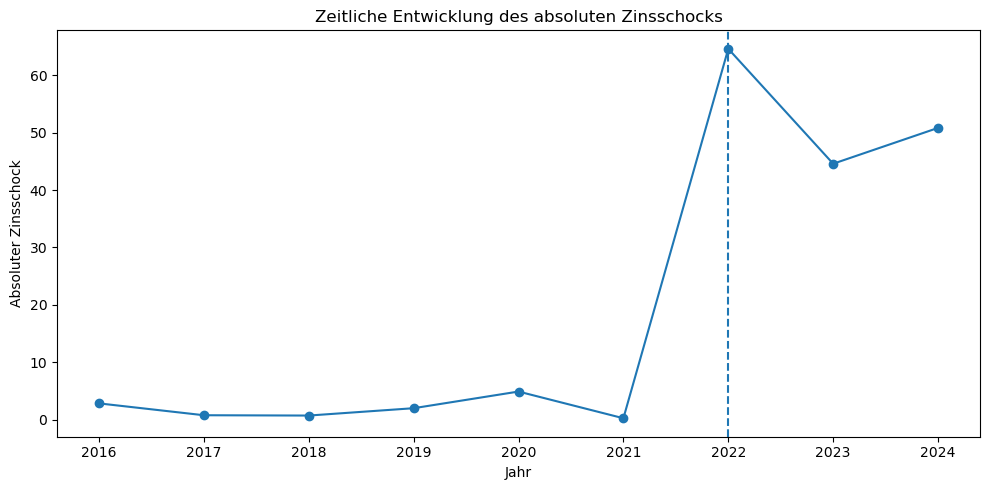

In [13]:
abs_zins_jahr = df.groupby("Jahr", as_index=False)["ABS"].mean()

print(abs_zins_jahr)

plt.figure(figsize=(10, 5))
plt.plot(abs_zins_jahr["Jahr"], abs_zins_jahr["ABS"], marker="o")
plt.axvline(x=2022, linestyle="--")
plt.title("Zeitliche Entwicklung des absoluten Zinsschocks")
plt.xlabel("Jahr")
plt.ylabel("Absoluter Zinsschock")
plt.tight_layout()
plt.show()

In [14]:
#Entwicklung der Eigenkapitalquote

   Jahr   EK_Quote
0  2016  44.842350
1  2017  45.314722
2  2018  44.350763
3  2019  44.456593
4  2020  43.758303
5  2021  43.861385
6  2022  43.758284
7  2023  44.168177
8  2024  44.067924


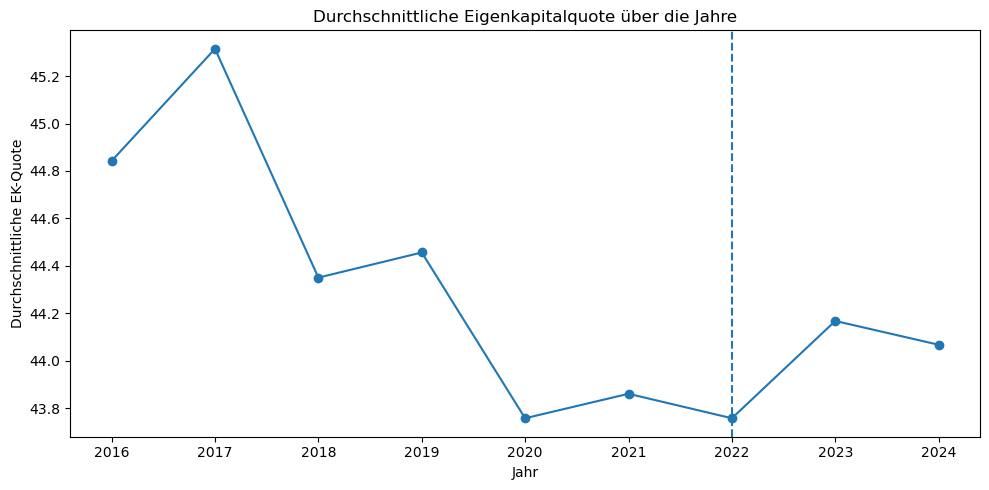

In [15]:
ek_jahr = df.groupby("Jahr", as_index=False)["EK_Quote"].mean()

print(ek_jahr)

plt.figure(figsize=(10, 5))
plt.plot(ek_jahr["Jahr"], ek_jahr["EK_Quote"], marker="o")
plt.axvline(2022, linestyle="--")
plt.title("Durchschnittliche Eigenkapitalquote über die Jahre")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche EK-Quote")
plt.tight_layout()
plt.show()

In [16]:
# High/Low-Gruppen einteilen
df["Leverage_Gruppe"] = np.where(
    df["Leverage_exante"] >= df["Leverage_exante"].median(),
    "High Leverage", "Low Leverage"
)

df["Liquidity_Gruppe"] = np.where(
    df["Liquidity_exante"] >= df["Liquidity_exante"].median(),
    "High Liquidity", "Low Liquidity"
)

df["STDebt_Gruppe"] = np.where(
    df["STDebtShare_exante"] >= df["STDebtShare_exante"].median(),
    "High ST Debt Share", "Low ST Debt Share"
)

df["Groesse_Gruppe"] = np.where(
    df["Groesse_Log_Bilanzsumme"] >= df["Groesse_Log_Bilanzsumme"].median(),
    "High Size", "Low Size"
)

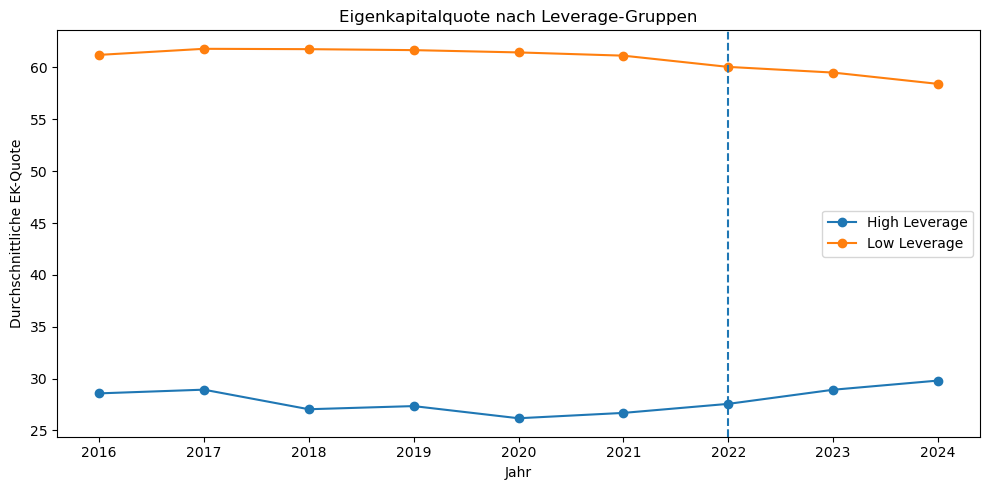

In [18]:
ek_lev = (
    df.groupby(["Jahr", "Leverage_Gruppe"])["EK_Quote"]
    .mean()
    .reset_index()
)

#Leverage Gruppen über Zeit plotten
plt.figure(figsize=(10, 5))
for gruppe in ek_lev["Leverage_Gruppe"].unique():
    temp = ek_lev[ek_lev["Leverage_Gruppe"] == gruppe]
    plt.plot(temp["Jahr"], temp["EK_Quote"], marker="o", label=gruppe)

plt.axvline(2022, linestyle="--")
plt.title("Eigenkapitalquote nach Leverage-Gruppen")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche EK-Quote")
plt.legend()
plt.tight_layout()

#plt.savefig("Leverage_Gruppen_plot_2016_2026.png", dpi=300)
plt.show()

In [ ]:
#Liquiditäts Gruppen über Zeit plotten
plt.figure(figsize=(10, 5))
for gruppe in ek_liq["Liquidity_Gruppe"].unique():
    temp = ek_liq[ek_liq["Liquidity_Gruppe"] == gruppe]
    plt.plot(temp["Jahr"], temp["EK_Quote"], marker="o", label=gruppe)

plt.axvline(2022, linestyle="--")
plt.title("Eigenkapitalquote nach Liquiditäts-Gruppen")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche EK-Quote")
plt.legend()
plt.tight_layout()

#plt.savefig("Liquidity_Gruppen_plot_2016_2026.png", dpi=300)
plt.show()

In [ ]:
#STDebtShare Gruppen über Zeit plotten
plt.figure(figsize=(10, 5))
for gruppe in ek_std["STDebt_Gruppe"].unique():
    temp = ek_std[ek_std["STDebt_Gruppe"] == gruppe]
    plt.plot(temp["Jahr"], temp["EK_Quote"], marker="o", label=gruppe)

plt.axvline(2022, linestyle="--")
plt.title("Eigenkapitalquote nach Short-term-Debt-Gruppen")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche EK-Quote")
plt.legend()
plt.tight_layout()

#plt.savefig("STDS_Gruppen_plot_2016_2026.png", dpi=300)
plt.show()

In [ ]:
#Unternehmensgrösse Gruppen über Zeit plotten
plt.figure(figsize=(10, 5))
for gruppe in ek_size["Groesse_Gruppe"].unique():
    temp = ek_size[ek_size["Groesse_Gruppe"] == gruppe]
    plt.plot(temp["Jahr"], temp["EK_Quote"], marker="o", label=gruppe)

plt.axvline(2022, linestyle="--")
plt.title("Eigenkapitalquote nach Unternehmensgröße")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche EK-Quote")
plt.legend()
plt.tight_layout()

#plt.savefig("Grösse_Gruppen_plot_2016_2026.png", dpi=300)
plt.show()